In [10]:
import pandas as pd
from tokenizers import Tokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_eval = pd.read_csv('data/eval.csv')

In [12]:
df_train.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word
0,"These people built, in stone, objects which th...","Quando esses objetos se foram, eles começaram ...",158,159,7,13
1,I've spent my whole life trying to win his aff...,"Passei minha vida tentando ganhar o amor, a ap...",101,95,11,9
2,I see you manage my family every day with grac...,Vejo você gerenciar minha família todos os dia...,124,126,11,12
3,"Five years ago, my friends moved to london, bu...","Há cinco anos, meus amigos se mudaram para lon...",111,122,12,13
4,"Illarion shevardnadze, don't come near me, or ...","Illarion shevardnadze, não se aproxime de mim ...",107,110,13,13


In [25]:
tokenizer = Tokenizer.from_file('artifacts/tokenizer_10000.json')

In [26]:
tokenizer.encode('Olá mundo, meu nome é João').tokens

['<BOS>',
 'O',
 'lá</w>',
 'mundo</w>',
 ',</w>',
 'meu</w>',
 'nome</w>',
 'é</w>',
 'Jo',
 'ão</w>',
 '<EOS>']

In [27]:
tokenizer.encode('Olá mundo, meu nome é João').ids

[5, 50, 1525, 1400, 443, 1106, 2274, 453, 5496, 752, 6]

In [28]:
tokenizer.decode(tokenizer.encode('Olá mundo, meu nome é João').ids)

'Olá mundo , meu nome é João'

In [29]:
vocabs_sizes = [500, 1000, 2000, 5000, 10000, 20000, 30000]


print('Declaring tokenizer...')
for vocab_size in tqdm([500, 1000, 5000, 10000, 25000, 30000, 50000]):
    tokenizer = Tokenizer.from_file(f'artifacts/tokenizer_{vocab_size}.json')
    
    df_train[f'len_tokens_{vocab_size}'] = df_train['en'].apply(lambda x: len(tokenizer.encode(x).ids))

    df_train[f'compress_{vocab_size}'] = df_train.apply(lambda x: x[f'len_tokens_{vocab_size}'] / x['en_length'], axis=1)

Declaring tokenizer...


100%|██████████| 7/7 [02:44<00:00, 23.54s/it]


In [30]:
columns_compress = [x for x in df_train.columns if 'compress' in x]
rename_columns = {x: x.replace('compress_', '') for x in columns_compress}
df_stats = df_train[columns_compress].rename(columns=rename_columns).describe()
df_stats

,500,1000,5000,10000,25000,30000,50000
count,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000
mean,0.839279,0.484715,0.309119,0.280811,0.258431,0.255462,0.249110
std,0.018499,0.034973,0.030836,0.028716,0.027642,0.027660,0.027875
min,0.596491,0.315315,0.197605,0.173554,0.157025,0.152174,0.144928
25%,0.826446,0.460938,0.287879,0.261146,0.239316,0.236364,0.229730
50%,0.838983,0.484127,0.307143,0.278846,0.256881,0.254237,0.247706
75%,0.851852,0.507937,0.327869,0.298246,0.275862,0.272727,0.266667
max,0.935185,0.909774,0.909774,0.909774,0.902256,0.902256,0.902256


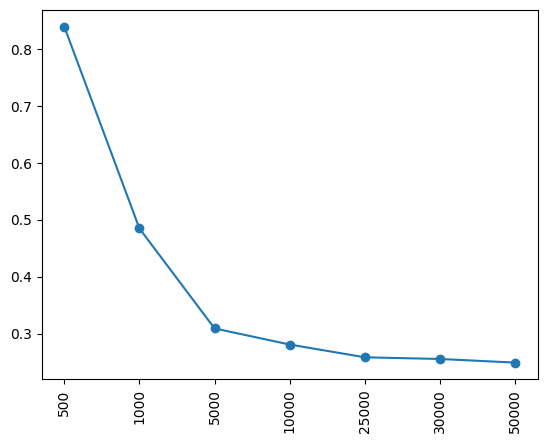

In [31]:
df_stats.T['mean'].plot.line(marker='o')
plt.xticks(rotation=90)
plt.show()

In [33]:
columns_tokens = [x for x in df_train.columns if 'len_tokens_' in x]
df_train[columns_tokens].describe(percentiles=[0.25, .5, .75, .8,.9, .95])


,len_tokens_500,len_tokens_1000,len_tokens_5000,len_tokens_10000,len_tokens_25000,len_tokens_30000,len_tokens_50000
count,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000
mean,102.434956,59.115804,37.676738,34.209466,31.465717,31.101389,30.322110
std,14.751604,9.124477,6.215651,5.586211,5.123399,5.072898,4.983554
min,68.000000,34.000000,21.000000,18.000000,17.000000,17.000000,16.000000
25%,91.000000,52.000000,33.000000,30.000000,28.000000,27.000000,27.000000
50%,99.000000,57.000000,37.000000,33.000000,31.000000,30.000000,30.000000
75%,111.000000,65.000000,41.000000,38.000000,35.000000,34.000000,33.000000
80%,115.000000,67.000000,43.000000,39.000000,36.000000,35.000000,34.000000
90%,125.000000,72.000000,46.000000,42.000000,39.000000,38.000000,37.000000
95%,133.000000,77.000000,49.000000,45.000000,41.000000,40.000000,40.000000
